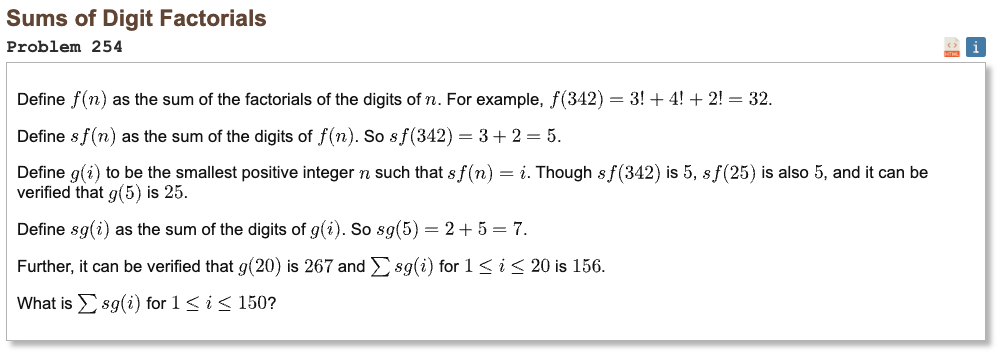

## Initial approach

* precompute factorials of digits 0 to 9 so digit factorial sum is fast
* instead of scanning all n, generate numbers by digit multiset in increasing numeric order
* build numbers with nondecreasing digits so the first time you see a digit multiset it is the smallest number for that pattern
* for each candidate number, compute f(n), then compute digit sum of f(n)
* when a new target value i is reached for the first time, store that number as g(i)
* keep going until all i from 1 to 150 are found
* finally sum the digit sums of all g(i)

In [1]:
from math import factorial

def digit_sum(n):
    s = 0
    while n > 0:
        s += n % 10
        n //= 10
    return s

def solve():
    fact = [factorial(i) for i in range(10)]
    max_i = 150

    found = {}
    total = 0

    def dfs(start_digit, current_digits):
        nonlocal total
        if len(found) == max_i:
            return

        if current_digits:
            n = 0
            for d in current_digits:
                n = n * 10 + d

            fn = 0
            for d in current_digits:
                fn += fact[d]

            s = digit_sum(fn)

            if 1 <= s <= max_i and s not in found:
                found[s] = n
                total += digit_sum(n)
                if len(found) == max_i:
                    return

        for d in range(start_digit, 10):
            if len(current_digits) > 20:
                break
            current_digits.append(d)
            dfs(d, current_digits)
            current_digits.pop()

    dfs(1, [])

    print("Result:", total)

In [2]:
%%time
solve()

Result: 2248
CPU times: user 20 s, sys: 110 ms, total: 20.2 s
Wall time: 20.2 s
